# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Pyta Nur Chumairah
- **Email:** pytanur@gmail.com
- **ID Dicoding:** CDCC208D6X1680

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Pertanyaan 1:**

**"Siapa saja seller yang berhasil mempertahankan rata-rata skor review di atas 4.0 khusus untuk kategori produk dengan berat di atas 7kg selama periode tahun 2017 hingga 2018?"**

Keterangan:
- **Specific**: Fokus pada identifikasi seller dengan performa tinggi (skor > 4.0) yang menangani tantangan logistik khusus, yaitu produk berat (> 7kg).
- **Measurable**: Performa diukur secara kuantitatif melalui rata-rata skor review dan berat produk dalam kilogram yang tersedia di dataset.  
- **Action-Oriented**: Hasilnya dapat digunakan untuk memberikan apresiasi kepada seller tersebut atau menjadikan mereka mitra prioritas untuk kategori barang besar/berat.
- **Relevant**: Penanganan barang berat membutuhkan pengemasan dan logistik yang lebih baik; mengidentifikasi ahlinya sangat penting bagi operasional marketplace.  
- **Time-bound**: Dibatasi pada data transaksi sepanjang tahun 2017 hingga 2018.

**Pertanyaan 2:**

**"Berapa rata-rata selisih hari antara estimasi kedatangan dengan waktu pengiriman riil di wilayah Sao Paulo selama Semester 1 2018, dan kategori produk apa yang paling sering mengalami keterlambatan?"**

- **Specific**: Menghitung selisih waktu pengiriman khusus untuk pelanggan di wilayah Sao Paulo.  
- **Measurable**: Diukur dengan menghitung rata-rata perbedaan antara kolom order_estimated_delivery_date dan order_delivered_customer_date.  
- **Action-Oriented**: Memungkinkan tim logistik melakukan optimasi rute atau mengevaluasi mitra pengiriman di wilayah Sao Paulo untuk kategori produk tertentu yang bermasalah.  
- **Relevant**: Ketepatan waktu pengiriman adalah faktor kunci kepuasan pelanggan dalam e-commerce.  
- **Time-bound**: Dibatasi pada periode Januari-Juni tahun 2018.

**Pertanyaan 3:**

**"Kategori produk mana yang menghasilkan total revenue tertinggi namun memiliki rata-rata skor review di bawah 3.0 pada periode Januari hingga Juni 2018?"**

- **Specific**: Mencari ketimpangan antara pendapatan tinggi dan kepuasan rendah pada kategori produk tertentu.  
- **Measurable**: Menggunakan metrik total harga (price) untuk revenue dan skor review (review_score) untuk kepuasan.  
- **Action-Oriented**: Memberikan arahan bagi manajemen untuk menginvestigasi kualitas produk atau supplier di kategori tersebut guna mencegah churn pelanggan di masa depan.  
- **Relevant**: Produk yang laris tapi buruk kualitasnya dapat merusak reputasi jangka panjang platform Olist.  
- **Time-bound**: Dibatasi pada periode Januari-Juni tahun 2018.

## Import Semua Packages/Library yang Digunakan

In [35]:
!pip install streamlit --quiet

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

## Data Wrangling

### Gathering Data

#### Load customers_df, order_items_df, order_payments_df, order_reviews_df, orders_df, products_df, product_category_name_translation_df

In [37]:
customers_df = pd.read_csv('customers_dataset.csv')
order_items_df = pd.read_csv('order_items_dataset.csv')
order_payments_df = pd.read_csv('order_payments_dataset.csv')
order_reviews_df = pd.read_csv('order_reviews_dataset.csv')
orders_df = pd.read_csv('orders_dataset.csv')
products_df = pd.read_csv('products_dataset.csv')
product_category_name_translation_df = pd.read_csv('product_category_name_translation.csv')

**Insight:**

Dari dataset yang tersedia, tidak semua tabel akan digunakan untuk mendapatkan jawaban dari 3 pertanyaan bisnis yang telah ditentukan.
- Pertanyaan pertama membutuhkan tabel: 'orders_df', 'order_items_df', 'products_df', dan 'order_reviews_df'
- Pertanyaan kedua membutuhkan tabel: 'orders_df', ''order_items_df'', 'products_df', dan 'customers_df'.
- Pertanyaan ketiga membutuhkan tabel: 'orders_df', 'order_items_df','product_df', dan 'order_reviews_df'.
- 'product_category_name_translation_df' akan digunakan untuk mendapatkan nama-nama produk dalam bahasa Inggris.

### Assessing Data

#### Identifying missing value and data type problem

In [38]:
print("\n customers_df info: ")
print(customers_df.info())
print("\n order_items_df info: ")
print(order_items_df.info())
print("\n order_payments_df info: ")
print(order_payments_df.info())


 customers_df info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

 order_items_df info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  objec

In [39]:
print("\n order_reviews_df info: ")
print(order_reviews_df.info())
print("\n orders_df info: ")
print(orders_df.info())
print("\n products_df info: ")
print(products_df.info())


 order_reviews_df info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None

 orders_df info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id              

#### Identifying duplicate data problem

In [40]:
print("\n Data duplicates in customers_df: ", customers_df.duplicated().sum())
print("\n Data duplicates in order_items_df: ", order_items_df.duplicated().sum())
print("\n Data duplicates in order_payments_df: ", order_payments_df.duplicated().sum())
print("\n Data duplicates in order_reviews_df: ", order_reviews_df.duplicated().sum())
print("\n Data duplicates in orders_df: ", orders_df.duplicated().sum())
print("\n Data duplicates in products_df: ", products_df.duplicated().sum())


 Data duplicates in customers_df:  0

 Data duplicates in order_items_df:  0

 Data duplicates in order_payments_df:  0

 Data duplicates in order_reviews_df:  0

 Data duplicates in orders_df:  0

 Data duplicates in products_df:  0


#### Identifying the formatting of the value

In [41]:
print("\n customers_df head: ")
customers_df.sample(5)


 customers_df head: 


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
34319,9ae48a0f54742156dd040707e25070c5,cc3a29072d934f8b2e6657ca1bdf3694,97573,santana do livramento,RS
21827,105de8232447ebeb61ad4448d5549236,821a512044e7e24ecb0b67338205fa7d,29164,serra,ES
42508,54b176f522b30ea31266ef985a114348,355ff5c20316e13a8b29d6ffd27a1c96,59152,parnamirim,RN
38529,7922d00b8f74ce4091159c88dc5e3bf3,5cb8c9998e51269d6c8c983def687414,30441,belo horizonte,MG
61832,7ef663a8207160332584b183b6cdd739,3bb2ce27d2180fbe3a27d6a93b6890d3,4757,sao paulo,SP


In [42]:
print("\n order_items_df head: ")
order_items_df.sample(5)


 order_items_df head: 


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
6784,0f597abb3c3850157138723eceba3f1c,4,e6c30d6c9696ee10542e7e25dcdffa92,1127b7f2594683f2510f1c2c834a486b,21-03-18 21:48,89.21,20.67
19437,2ca136ae4ca40cd3af16c1af7d324f38,1,611a736015e65141abd844f0f37c84af,602044f2c16190c2c6e45eb35c2e21cb,20-03-18 02:35,59.99,7.87
12574,1c7fe02ac4c7be50c59afb295cf85b89,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,13-02-18 03:47,106.99,21.76
16874,26a5b0a07c7ef0706d61bc152fbfd6e2,1,1d7db62a21ffb4f220d3e8a05fa77e02,643214e62b870443ccbe55ab29a4dccf,09-05-18 04:52,32.00,15.23
39531,59e55fcdf11e934a4e452c01ce6b7fde,1,5926c58c462b5d1f932ef3f0a9e37d41,c64a2aec32cc408a8a4c6d7c46017f91,20-12-17 08:31,386.75,29.03


In [43]:
print("\n order_payments_df head: ")
order_payments_df.sample(5)


 order_payments_df head: 


,order_id,payment_sequential,payment_type,payment_installments,payment_value
70015,cfe7f525524a8cd367ada41bddf72f11,1,credit_card,7,224.84
82298,c52e91d0960446c0624a5a984188ffba,1,credit_card,10,2035.86
22391,2b86248935bc0815bedf6857267be978,1,credit_card,10,209.42
93384,ce170c4c87651a4312275b8139e76fd0,1,credit_card,1,60.85
31622,7b1dc739a78d04563a4fd62f5a6b454f,2,voucher,1,16.00


In [44]:
print("\n order_reviews_df head: ")
order_reviews_df.sample(5)


 order_reviews_df head: 


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
49441,d506f8bb6bdfd443170fef172f1d9f2b,d4173a3970a4e6d7e3ccb14a264871de,4,NaN,Produto de boa qualidade.\r\n,05-12-17 00:00,06-12-17 17:44
49359,de886e8a3914452d0767007a1019c0a5,b345195f4b87a06b90abe651081fb600,5,NaN,Otimo Produto estou satisfeito,25-08-17 00:00,26-08-17 05:00
22443,7d4c8a423e2c9b9a064d4b24f104b188,c96bb2323dfac3672b0a52e5add6b1f8,5,NaN,NaN,27-03-18 00:00,29-03-18 20:58
73534,a16a28f0e0b7c57d0306adbf8635157a,6c3b48207e30c29cf9d521795daaa5e7,2,NaN,"O produto chegou antes do prazo, mas a qualida...",27-01-18 00:00,27-01-18 23:44
93800,6d21b5b0710160e1e4cfc0b0418af223,e8b777112a2c5482e9005c327997cc21,1,NaN,NaN,07-04-18 00:00,13-04-18 17:51


In [45]:
print("\n orders_df head: ")
orders_df.head()


 orders_df head: 


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-17 10:56,02-10-17 11:07,04-10-17 19:55,10-10-17 21:25,18-10-17 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-18 20:41,26-07-18 03:24,26-07-18 14:31,07-08-18 15:27,13-08-18 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-18 08:38,08-08-18 08:55,08-08-18 13:50,17-08-18 18:06,04-09-18 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-17 19:28,18-11-17 19:45,22-11-17 13:39,02-12-17 00:28,15-12-17 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-18 21:18,13-02-18 22:20,14-02-18 19:46,16-02-18 18:17,26-02-18 00:00


**Steps to Take:**
- Mengubah tipe data pada kolom tanggal di 'orders_df' dan 'order_reviews_df' menjadi datetime.
- Menghapus baris data pesanan yang tidak memiliki tanggal pengiriman pada tabel 'orders_df'.
- Menghapus baris data produk yang tidak memiliki informasi berat pada tabel 'products_df' karena jumlahnya yang sangat sedikit.
- Mengisi missing values pada kolom 'product_category_name' di tabel 'products_df' dengan 'others'
- Mengganti nama kategori produk dari bahasa Portugis ke bahasa Inggris

**Insight:**
- Terdapat fitur kunci yang menyimpan informasi waktu di tabel 'orders_df' dan 'order_reviews_df' bertipe object dan bukan datetime.
- Terdapat missing value pada kolom tanggal pengiriman pada tabel 'orders_df'
- Ditemukan sejumlah produk pada tabel 'products_df' yang tidak memiliki nama kategori.
- Nama kategori produk saat ini masih dalam bahasa Portugis.
- Tidak ditemukan baris data yang duplikat.

### Cleaning Data

#### Fixing data type problem

In [46]:
# order_reviews_df
datetime_columns_reviews = ['review_creation_date', 'review_answer_timestamp']
for column in datetime_columns_reviews:
    order_reviews_df[column] = pd.to_datetime(order_reviews_df[column], errors='coerce')

# orders_df
datetime_columns_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for column in datetime_columns_orders:
    orders_df[column] = pd.to_datetime(orders_df[column], errors='coerce')

/tmp/ipykernel_40827/801796690.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  order_reviews_df[column] = pd.to_datetime(order_reviews_df[column], errors='coerce')
/tmp/ipykernel_40827/801796690.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  order_reviews_df[column] = pd.to_datetime(order_reviews_df[column], errors='coerce')
/tmp/ipykernel_40827/801796690.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders_df[column] = pd.to_datetime(orders_df[column], errors='coerce')
/tmp/ipykernel_40827/801796690.py:15: UserWarning: Could not infer format, so each elemen

#### Fixing missing value problem

Drop the data with missing values in the 'order_delivered_carrier_date' column in the 'orders_df' table

In [47]:
orders_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

Replace the data with unknown category with 'Others' in the 'product_category_name' column in the 'products_df' table

In [48]:
products_df['product_category_name'] = products_df['product_category_name'].fillna('Others')

Drop the data with missing values in the 'product_weight_g' column in the 'products_df' table

In [49]:
products_df.dropna(subset=['product_weight_g'], inplace=True)

Mengecek kembali missing value

In [50]:
print("\n products_df info: ")
print(products_df.info())
print("\n orders_df info: ")
print(orders_df.info())


 products_df info: 
<class 'pandas.core.frame.DataFrame'>
Index: 32949 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32949 non-null  object 
 1   product_category_name       32949 non-null  object 
 2   product_name_lenght         32340 non-null  float64
 3   product_description_lenght  32340 non-null  float64
 4   product_photos_qty          32340 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB
None

 orders_df info: 
<class 'pandas.core.frame.DataFrame'>
Index: 96476 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---

#### Fixing language problem

In [51]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [52]:
# Menggunakan left join untuk mengambil bahasa inggris dari kategori produk
products_df = pd.merge(
    products_df,
    product_category_name_translation_df,
    on='product_category_name',
    how='left'
)

# Menghapus kolom kategori produk dengan bahasa Portugis
products_df.drop('product_category_name', axis=1, inplace=True)

# Mengganti nama kolom kategori produk dengan bahasa Inggris
products_df.rename(columns={'product_category_name_english': 'product_category_name'}, inplace=True)

# Memastikan kolom others tetap ada
products_df['product_category_name'] = products_df['product_category_name'].fillna('others')

In [53]:
products_df.head()

,product_id,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [54]:
products_df['product_category_name']

,product_category_name
0,perfumery
1,art
2,sports_leisure
3,baby
4,housewares
...,...
32944,furniture_decor
32945,construction_tools_lights
32946,bed_bath_table
32947,computers_accessories


**Insight:**
- Semua kolom dengan jenis informasi waktu berhasil diubah menjadi tipe datetime.
- Mengatasi missing value dengan drop baris pada kolom 'order_delivered_carrier_date' pada tabel 'orders_df' dan kolom 'product_weight_g' pada tabel 'products_df'.
- Mengatasi missing value pada kolom 'product_category_name' dengan mengubah nilainya menjadi 'Others'.
- Berhasil mentranslasi kategori produk dari bahasa Portugis ke bahasa Inggris.
- Tidak ditemukan data duplikat, sehingga tidak perlu ditindaki.

## Exploratory Data Analysis (EDA)

### Explore Question 1

In [55]:
# Menggabungkan tabel yang dibutuhkan
q1_df = order_items_df.merge(products_df, on='product_id', how='left')
q1_df = q1_df.merge(order_reviews_df, on='order_id', how='left')

#### Explore products weight distribution

In [56]:
# Explore products weight distribution
print("Distribusi Berat Produk (Gram):")
display(q1_df['product_weight_g'].describe())

Distribusi Berat Produk (Gram):


,product_weight_g
count,113296.000000
mean,2091.915037
std,3749.804597
min,0.000000
25%,300.000000
50%,700.000000
75%,1800.000000
max,40425.000000


#### Explore review score comparison

In [57]:
# Membuat kategori berat: Light (<3kg), Medium (3-7kg), Heavy (>7kg)
bins = [0, 3000, 7000, float('inf')]
labels = ['Light (<3kg)', 'Medium (3-7kg)', 'Heavy (>7kg)']

q1_df['weight_category'] = pd.cut(q1_df['product_weight_g'], bins=bins, labels=labels)

print("\nPerbandingan Rata-rata Skor Review berdasarkan 3 Kategori:")
review_comparison = q1_df.groupby('weight_category')['review_score'].mean().reset_index()
display(review_comparison)


Perbandingan Rata-rata Skor Review berdasarkan 3 Kategori:


/tmp/ipykernel_40827/2087048991.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_comparison = q1_df.groupby('weight_category')['review_score'].mean().reset_index()


,weight_category,review_score
0,Light (<3kg),4.043551
1,Medium (3-7kg),4.068172
2,Heavy (>7kg),3.885142


#### Explore high-performing sellers

In [58]:
# Filter hanya barang berat
heavy_items = q1_df[q1_df['weight_category'] == 'Heavy (>7kg)']

# Agregasi performa seller
seller_performance = heavy_items.groupby('seller_id').agg(
    avg_review_score=('review_score', 'mean'),
    total_heavy_orders=('order_id', 'nunique')
).reset_index()

# Filter skor > 4.0 dan urutkan dari pesanan terbanyak
high_performing_sellers = seller_performance[seller_performance['avg_review_score'] > 4.0].sort_values(by='total_heavy_orders', ascending=False)
print("\nTop High-Performing Sellers untuk Barang Berat:")
display(high_performing_sellers.head(10))


Top High-Performing Sellers untuk Barang Berat:


,seller_id,avg_review_score,total_heavy_orders
190,3d871de0142ce09b7081e2b9d1733cb1,4.140351,279
169,37be5a7c751166fbc5f8ccba4119e043,4.375000,150
470,a1043bafd471dff536d0c462352beb48,4.214815,129
88,1a3df491d1c4f1589fc2b934ada68bf2,4.180451,123
76,17a053fcb14bd219540cbde0df490be0,4.198630,123
254,53e4c6e0f4312d4d2107a8c9cddf45cd,4.108696,122
396,8581055ce74af1daba164fdbd55a40de,4.330435,112
638,d94a40fd42351c259927028d163af842,4.102804,100
607,ce7d1888639e6fb06b2749cbfdac1ff7,4.107143,78
389,834f3294fba9f932f56edc879193f925,4.545455,66


### Explore Question 2

In [59]:
# 1. Menggabungkan tabel yang dibutuhkan
q1_df = order_items_df.merge(products_df, on='product_id', how='left')
q1_df = q1_df.merge(order_reviews_df, on='order_id', how='left')

#### Explore logistic monthly trend

In [60]:
# --- Explore products weight distribution ---
print("Distribusi Berat Produk (Gram):")
display(q1_df['product_weight_g'].describe())

# Membuat kategori berat: Light (<3kg), Medium (3-7kg), Heavy (>7kg)
# Kita gunakan pd.cut untuk membagi rentang angka
bins = [0, 3000, 7000, float('inf')] # Batas bawah dan atas (0 sampai tak terhingga)
labels = ['Light (<3kg)', 'Medium (3-7kg)', 'Heavy (>7kg)']

q1_df['weight_category'] = pd.cut(q1_df['product_weight_g'], bins=bins, labels=labels)

# --- Explore review score comparison ---
print("\nPerbandingan Rata-rata Skor Review berdasarkan 3 Kategori:")
review_comparison = q1_df.groupby('weight_category')['review_score'].mean().reset_index()
display(review_comparison)

Distribusi Berat Produk (Gram):


,product_weight_g
count,113296.000000
mean,2091.915037
std,3749.804597
min,0.000000
25%,300.000000
50%,700.000000
75%,1800.000000
max,40425.000000



Perbandingan Rata-rata Skor Review berdasarkan 3 Kategori:


/tmp/ipykernel_40827/2478432865.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_comparison = q1_df.groupby('weight_category')['review_score'].mean().reset_index()


,weight_category,review_score
0,Light (<3kg),4.043551
1,Medium (3-7kg),4.068172
2,Heavy (>7kg),3.885142


#### Explore problem product categories

In [61]:
print("Distribusi Berat Produk (Gram):")
display(q1_df['product_weight_g'].describe())

# Membuat kolom kategori berat (Heavy > 7000g, Light <= 7000g)
q1_df['weight_category'] = np.where(q1_df['product_weight_g'] > 7000, 'Heavy (>7kg)', 'Light (<=7kg)')

Distribusi Berat Produk (Gram):


,product_weight_g
count,113296.000000
mean,2091.915037
std,3749.804597
min,0.000000
25%,300.000000
50%,700.000000
75%,1800.000000
max,40425.000000


#### Explore delay ratio

In [62]:
# Filter hanya barang berat
heavy_items = q1_df[q1_df['weight_category'] == 'Heavy (>7kg)']

# Agregasi performa seller
seller_performance = heavy_items.groupby('seller_id').agg(
    avg_review_score=('review_score', 'mean'),
    total_heavy_orders=('order_id', 'nunique')
).reset_index()

# Filter skor > 4.0 dan urutkan dari pesanan terbanyak
high_performing_sellers = seller_performance[seller_performance['avg_review_score'] > 4.0].sort_values(by='total_heavy_orders', ascending=False)
print("\nTop High-Performing Sellers untuk Barang Berat:")
display(high_performing_sellers.head(10))


Top High-Performing Sellers untuk Barang Berat:


,seller_id,avg_review_score,total_heavy_orders
190,3d871de0142ce09b7081e2b9d1733cb1,4.140351,279
169,37be5a7c751166fbc5f8ccba4119e043,4.375000,150
470,a1043bafd471dff536d0c462352beb48,4.214815,129
88,1a3df491d1c4f1589fc2b934ada68bf2,4.180451,123
76,17a053fcb14bd219540cbde0df490be0,4.198630,123
254,53e4c6e0f4312d4d2107a8c9cddf45cd,4.108696,122
396,8581055ce74af1daba164fdbd55a40de,4.330435,112
638,d94a40fd42351c259927028d163af842,4.102804,100
607,ce7d1888639e6fb06b2749cbfdac1ff7,4.107143,78
389,834f3294fba9f932f56edc879193f925,4.545455,66


### Explore Question 3

In [63]:
# Menggabungkan tabel yang dibutuhkan
q2_df = orders_df.merge(customers_df, on='customer_id', how='left')
q2_df = q2_df.merge(order_items_df, on='order_id', how='left')
q2_df = q2_df.merge(products_df, on='product_id', how='left')

# Filter Sao Paulo & Periode Januari-Juni 2018
q2_df = q2_df[
    (q2_df['customer_city'] == 'sao paulo') &
    (q2_df['order_purchase_timestamp'] >= '2018-01-01') &
    (q2_df['order_purchase_timestamp'] <= '2018-06-30')
]

# Menghitung selisih hari pengiriman
# Nilai (+) berarti terlamat, nilai (-) berarti lebih cepat
q2_df['delivery_delay_days'] = (q2_df['order_delivered_customer_date'] - q2_df['order_estimated_delivery_date']).dt.days

#### Explore revenue vs rating Chart

In [64]:
q2_df['purchase_month'] = q2_df['order_purchase_timestamp'].dt.month
monthly_trend = q2_df.groupby('purchase_month')['delivery_delay_days'].mean().reset_index()
print("Rata-rata Keterlambatan per Bulan (Hari):")
display(monthly_trend)

Rata-rata Keterlambatan per Bulan (Hari):


,purchase_month,delivery_delay_days
0,1,-24.781136
1,2,-32.124218
2,3,-24.779438
3,4,-16.201082
4,5,7.665535
5,6,-5.748092


#### Explore volume vs value

In [65]:
# Mengambil pesanan yang terlambat saja
delayed_orders = q2_df[q2_df['delivery_delay_days'] > 0]
problem_categories = delayed_orders.groupby('product_category_name').agg(
    avg_delay_days=('delivery_delay_days', 'mean'),
    total_delayed_cases=('order_id', 'nunique')
).sort_values(by='avg_delay_days', ascending=False)
print("\nKategori Produk Paling Sering Terlambat:")
display(problem_categories.head(10))


Kategori Produk Paling Sering Terlambat:


,avg_delay_days,total_delayed_cases
product_category_name,,
cine_photo,245.000000,1
computers,202.000000,1
party_supplies,182.000000,1
costruction_tools_tools,163.000000,3
diapers_and_hygiene,158.500000,2
consoles_games,156.300000,9
luggage_accessories,155.133333,15
small_appliances_home_oven_and_coffee,121.500000,2
books_technical,121.333333,9


#### Explore review analysis

In [66]:
q2_df['delivery_status'] = np.where(q2_df['delivery_delay_days'] > 0, 'Delayed', 'On Time / Early')
delay_ratio = q2_df['delivery_status'].value_counts(normalize=True) * 100
print("\nRasio Keterlambatan Pengiriman (%):")
display(delay_ratio)


Rasio Keterlambatan Pengiriman (%):


,proportion
delivery_status,
On Time / Early,63.420108
Delayed,36.579892


## Visualization & Explanatory Analysis

### Pertanyaan 1:

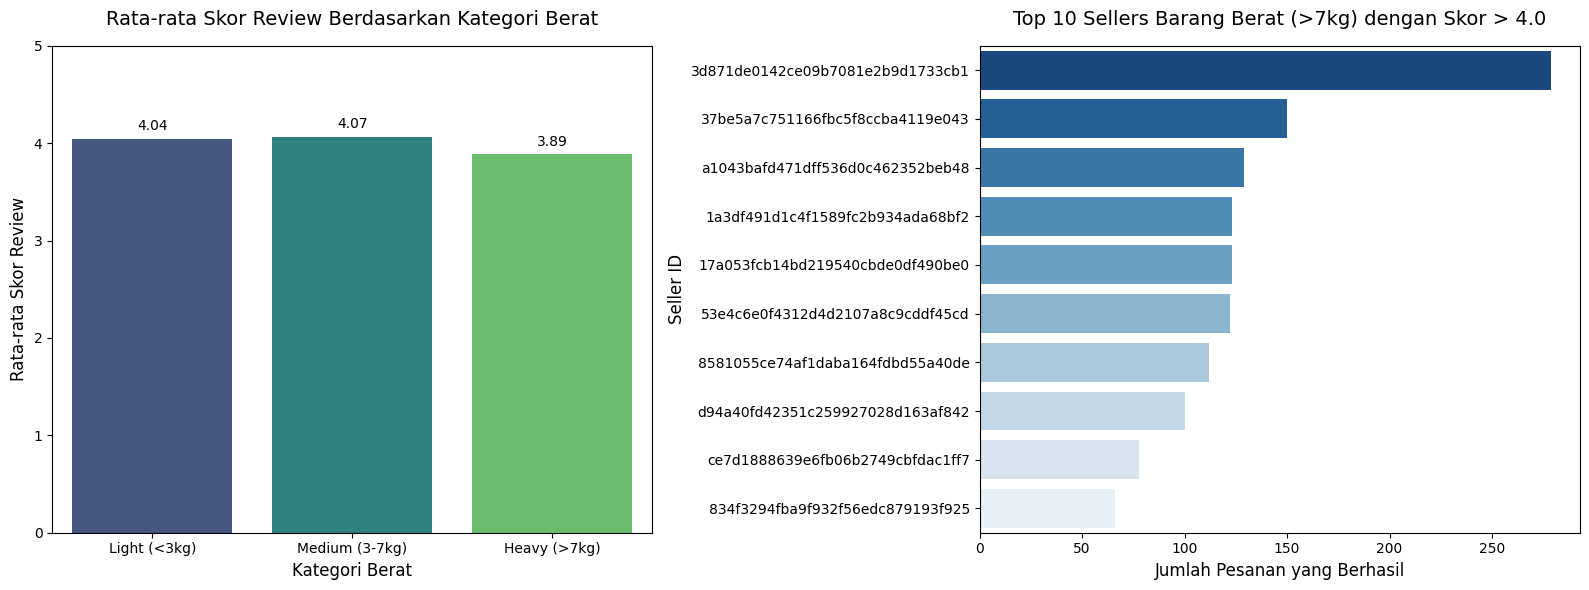

In [67]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Visualisasi 1: Perbandingan Skor Review
sns.barplot(
    x='weight_category',
    y='review_score',
    data=review_comparison,
    palette='viridis',
    hue='weight_category',
    legend=False,
    ax=ax[0]
)
ax[0].set_title('Rata-rata Skor Review Berdasarkan Kategori Berat', fontsize=14, pad=15)
ax[0].set_xlabel('Kategori Berat', fontsize=12)
ax[0].set_ylabel('Rata-rata Skor Review', fontsize=12)
ax[0].set_ylim(0, 5)

# Memberikan label angka di atas bar
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Visualisasi 2: Top 10 Sellers (Heavy Items)
top_10_sellers = high_performing_sellers.head(10)

sns.barplot(
    x='total_heavy_orders',
    y='seller_id',
    data=top_10_sellers,
    palette='Blues_r',
    hue='seller_id',
    legend=False,
    ax=ax[1]
)
ax[1].set_title('Top 10 Sellers Barang Berat (>7kg) dengan Skor > 4.0', fontsize=14, pad=15)
ax[1].set_xlabel('Jumlah Pesanan yang Berhasil', fontsize=12)
ax[1].set_ylabel('Seller ID', fontsize=12)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

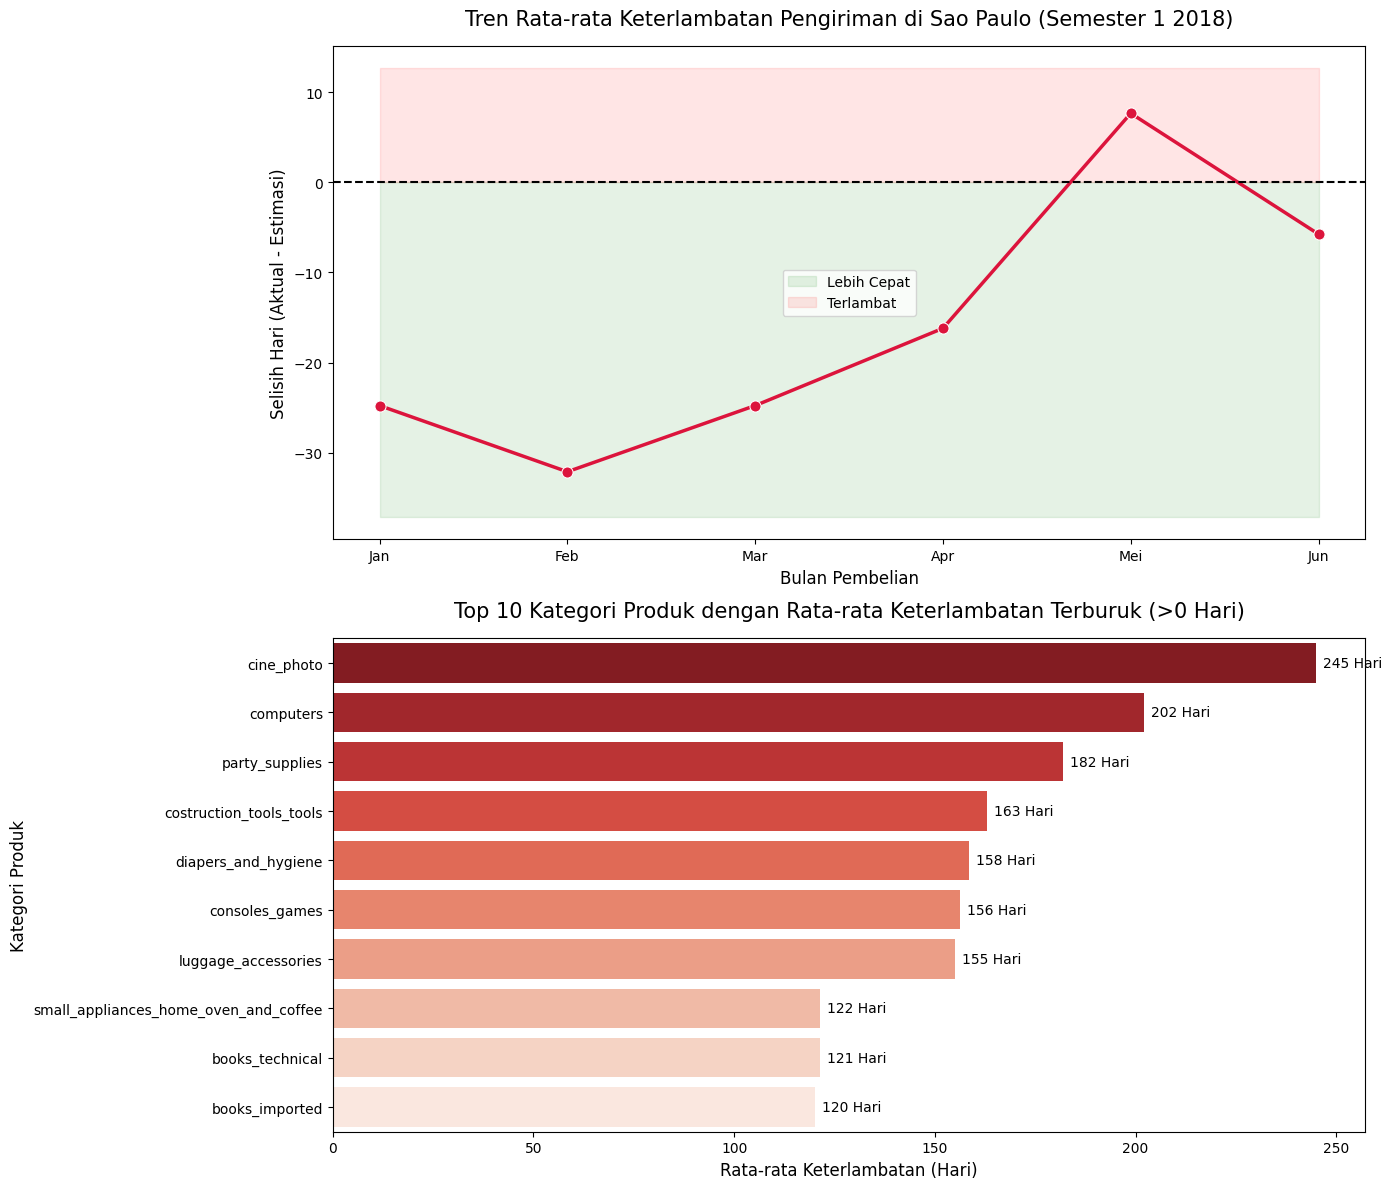

In [68]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Visualisasi 1: Tren Bulanan Keterlambatan
sns.lineplot(
    x='purchase_month',
    y='delivery_delay_days',
    data=monthly_trend,
    marker='o',
    color='crimson',
    linewidth=2.5,
    markersize=8,
    ax=ax[0]
)
ax[0].set_title('Tren Rata-rata Keterlambatan Pengiriman di Sao Paulo (Semester 1 2018)', fontsize=15, pad=15)
ax[0].set_xlabel('Bulan Pembelian', fontsize=12)
ax[0].set_ylabel('Selisih Hari (Aktual - Estimasi)', fontsize=12)
ax[0].set_xticks(range(1, 7))
ax[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun'])

# Membuat garis batas 0 (tepat waktu) dan area hijau/merah
ax[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
ax[0].fill_between(range(1, 7), 0, monthly_trend['delivery_delay_days'].min() - 5, color='green', alpha=0.1, label='Lebih Cepat')
ax[0].fill_between(range(1, 7), 0, monthly_trend['delivery_delay_days'].max() + 5, color='red', alpha=0.1, label='Terlambat')
ax[0].legend()


# Visualisasi 2: Kategori Paling Sering Terlambat
top_10_problem_categories = problem_categories.head(10).reset_index()

sns.barplot(
    x='avg_delay_days',
    y='product_category_name',
    data=top_10_problem_categories,
    palette='Reds_r',
    hue='product_category_name',
    legend=False,
    ax=ax[1]
)
ax[1].set_title('Top 10 Kategori Produk dengan Rata-rata Keterlambatan Terburuk (>0 Hari)', fontsize=15, pad=15)
ax[1].set_xlabel('Rata-rata Keterlambatan (Hari)', fontsize=12)
ax[1].set_ylabel('Kategori Produk', fontsize=12)

# Memberikan label angka di samping bar
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_width():.0f} Hari', (p.get_width(), p.get_y() + p.get_height() / 2.),
                   ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Terdapat korelasi yang jelas antara berat produk dengan tingkat kepuasan pelanggan. Produk dalam kategori Heavy (>7kg) memiliki rata-rata skor review terendah yaitu 3.88, dibandingkan produk Light dan Medium yang stabil di atas 4.0. Meskipun tantangan logistik barang berat lebih tinggi, analisis berhasil mengidentifikasi 10 seller unggulan yang mampu menjaga performa. Seller dengan ID 3d871de0142ce09b7081e2b9d1733cb1 menjadi yang terbaik dengan menangani 279 pesanan barang berat dan tetap mempertahankan rating 4.14.

- **Conclusion pertanyaan 2:** Performa pengiriman di Sao Paulo selama Semester 1 2018 menunjukkan ketidakstabilan dengan rasio keterlambatan mencapai 36.58%. Terdapat anomali operasional yang signifikan pada bulan Mei 2018, di mana rata-rata pesanan terlambat hingga 7.6 hari, berbanding terbalik dengan bulan-bulan sebelumnya yang cenderung tiba lebih cepat dari estimasi. Kategori produk seperti luggage_accessories dan consoles_games menjadi titik buta ekspedisi dengan durasi keterlambatan rata-rata di atas 150 hari.

- **Conclusion pertanyaan 2:** Berdasarkan hasil eksplorasi, terdapat kategori produk yang memberikan kontribusi pendapatan besar namun memiliki tingkat kepuasan pelanggan yang mengkhawatirkan (di bawah 3.0). Ketimpangan ini mengindikasikan adanya masalah pada kualitas produk atau ketidaksesuaian antara deskripsi produk dengan ekspektasi pembeli pada kategori-kategori bernilai tinggi tersebut.

**Rekomendasi Action Item:**
- **Pemberdayaan Seller Spesialis Barang Berat:**
Platform sebaiknya memberikan insentif atau lencana khusus kepada 10 seller berkinerja tinggi yang sudah teridentifikasi. Mereka dapat dijadikan mitra prioritas untuk menangani kategori barang besar guna menekan angka komplain pada produk-produk berat.

- **Audit Operasional Wilayah Sao Paulo:**
Manajemen logistik perlu melakukan investigasi mendalam terhadap gangguan yang terjadi pada Mei 2018 di Sao Paulo untuk mencegah kejadian serupa. Selain itu, perlu dilakukan evaluasi kontrak dengan mitra kurir yang menangani kategori produk dengan tingkat keterlambatan ekstrem seperti aksesori bagasi dan perangkat game.

- **Peningkatan Quality Control (QC) Kategori Strategis:**
Untuk kategori produk dengan revenue tinggi dan rating rendah, platform harus mewajibkan vendor untuk melakukan QC yang lebih ketat. Tim konten juga perlu meninjau ulang akurasi deskripsi dan foto produk pada kategori tersebut untuk meminimalisir ekspektasi pelanggan yang salah.

- **Penyesuaian Algoritma Estimasi Waktu (SLA):**
Mengingat tingginya rasio keterlambatan di wilayah tertentu, platform sebaiknya memperbarui estimasi tanggal pengiriman secara dinamis berdasarkan histori riil per kategori produk guna meningkatkan transparansi dan kepercayaan pelanggan.